<a href="https://colab.research.google.com/github/KCCalder/CSC502-XGBoost-Split-Finding/blob/main/XGBoost_Split_Finding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from collections import defaultdict
from sklearn.datasets import load_iris
from sklearn.datasets import fetch_california_housing

# For reproducability
np.random.seed(0)

In [2]:
# Toy data used for testing
def make_toy_data(n=100, d=3):
  X = np.random.randn(n, d)
  y = (X[:, 0] + X[:, 1] > 0).astype(float)
  return X, y

# Gradient and Hessian of squared error
def squared_err_grad_hess(y, y_pred):
  g = 2 * (y_pred - y)
  h = 2 * np.ones_like(y)
  return g, h

# Gradient and hessian of logistic loss
def log_loss_grad_hess(y, y_pred):
  # sigmoid
  p = 1 / (1 + np.exp(-y_pred))

  g = p - y
  h = p * (1 - p)

  return g, h

# Gain Function to evaluate splits (Equation 7 from paper)
def compute_gain(G_L, H_L, G_R, H_R, G, H, reg_lambda=1.0, gamma=0.0):
  left = (G_L ** 2) / (H_L + reg_lambda)
  right = (G_R ** 2) / (H_R + reg_lambda)
  parent = (G ** 2) / (H + reg_lambda)

  gain = 0.5 * (left + right - parent) - gamma
  return gain

# Support function for creating histogram bins
def weighted_quantile(vals, weights, quantiles):
  # sort values and associated weights
  sorter = np.argsort(vals)
  vals = vals[sorter]
  weights = weights[sorter]

  # sum the weights
  cumulative_weights = np.cumsum(weights)
  total_weight = cumulative_weights[-1]

  normalized = cumulative_weights / total_weight

  return np.interp(quantiles, normalized, vals)

# Exact Greedy Algorithm for Split Finding (Algorithm 1 from paper)
def greedy_split(X, g, h, reg_lambda=1.0, gamma=0.0):
  # initialization phase
  n_samples, m_features = X.shape
  best_gain = -np.inf
  best_feature = None
  best_thresh = None

  G = np.sum(g)
  H = np.sum(h)

  for k in range(m_features):
    G_L = 0.0
    H_L = 0.0
    # sort by feature
    sorted_idx = np.argsort(X[:, k])
    X_f = X[sorted_idx, k]
    g_f = g[sorted_idx]
    h_f = h[sorted_idx]

    for j in range(1, n_samples):
      # accumulate feature values to the let
      G_L += g_f[j - 1]
      H_L += h_f[j - 1]

      # accumulate feature values to the right (differnce from whole)
      G_R = G - G_L
      H_R = H - H_L

      # skip duplicate feature values
      if X_f[j] == X_f[j -1]:
        continue

      # compute the gain val using the current feature/threshold pair
      gain = compute_gain(G_L, H_L, G_R, H_R, G, H, reg_lambda, gamma)
      if gain > best_gain: # Update if gain is better
        best_gain = gain
        best_feature = k
        best_thresh = (X_f[j] + X_f[j - 1]) / 2.0

  return best_feature, best_thresh, best_gain

# Approximate algorithm for Split Finding (Algorithm 2 from paper)
def approx_split_histogram(X, g, h, max_bins=16, reg_lambda=1.0, gamma=0.0):
  # initialization phase
  n_samples, m_features = X.shape
  best_gain = -np.inf
  best_feature = None
  best_thresh = None

  G = np.sum(g)
  H = np.sum(h)

  for k in range(m_features):
    x = X[:, k]

    # build split candidates
    quantiles = np.linspace(0, 1, max_bins + 1)[1:-1]  # exclude 0 and 1
    split_candidates = weighted_quantile(x, h, quantiles)

    # exclude dublicates
    split_candidates = np.unique(split_candidates)

    # initialize bins
    bin_indices = np.searchsorted(split_candidates, x)
    n_bins = len(split_candidates) + 1

    G_bin = np.zeros(n_bins)
    H_bin = np.zeros(n_bins)

    # assign gs and hs to bins
    for i in range(n_samples):
      b = min(bin_indices[i], n_bins - 1)
      G_bin[b] += g[i]
      H_bin[b] += h[i]

    G_L = 0.0
    H_L = 0.0

    for j in range(n_bins - 1):
      # accumulate feature values to the left
      G_L += G_bin[j]
      H_L += H_bin[j]

      # accumulate feature values to the right (differnce from whole)
      G_R = G - G_L
      H_R = H - H_L

      # compute gain
      gain = compute_gain(G_L, H_L, G_R, H_R, G, H, reg_lambda, gamma)
      if gain > best_gain: # Update if gain is better
        best_gain = gain
        best_feature = k
        best_thresh = split_candidates[j]
  return best_feature, best_thresh, best_gain


# Plotting func for testing
def plot_split(X, y, feature, threshold_greedy, threshold_approx, feature_name):
  plt.scatter(X[:, feature], y)
  plt.axvline(threshold_greedy, color='red', label='Greedy Split')
  plt.axvline(threshold_approx, color='green', label='Approximate Split')
  plt.title(f"Feature {feature_name} split")
  plt.ylabel("House Value")
  plt.xlabel("Threshold")
  plt.legend()
  plt.show()
  return

# PLot the gain curve with lines for the selected feature thresholds
def plot_gain_curve(X, g, h, feature, greedy_split, approx_split, feature_name):
  # Filter the selected feature
  x = X[:, feature]
  sorted_idx = np.argsort(x)

  x_sorted = x[sorted_idx]
  g_sorted = g[sorted_idx]
  h_sorted = h[sorted_idx]

  G = np.sum(g)
  H = np.sum(h)

  G_L, H_L = 0, 0

  thresholds = []
  gains = []

  # Find the gain for everyy possible split (similar to greedy alg)
  for i in range(1, len(x)):
      G_L += g_sorted[i-1]
      H_L += h_sorted[i-1]

      if x_sorted[i] == x_sorted[i-1]:
            continue

      G_R = G - G_L
      H_R = H - H_L

      gain = compute_gain(G_L, H_L, G_R, H_R, G, H)

      thresholds.append((x_sorted[i] + x_sorted[i-1]) / 2)
      gains.append(gain)

  # Make the gain plot
  plt.plot(thresholds, gains)
  plt.axvline(greedy_split, color='red', label='Greedy Split')
  plt.axvline(approx_split, color='green', label='Approximate Split')
  plt.xlabel("Threshold")
  plt.ylabel("Gain")
  plt.title(f"Gain Curve (Feature {feature_name})")
  plt.legend()
  plt.show()

In [4]:
# Unit Tests

def run_split_test(X, y, name=""):
  print(f"\n=== {name} ===")

  y_pred = np.zeros_like(y)
  g, h = log_loss_grad_hess(y, y_pred)

  f_g, t_g, gain_g = greedy_split(X, g, h)
  f_h, t_h, gain_h = approx_split_histogram(X, g, h)

  print(f"Greedy  -> feature: {f_g}, threshold: {t_g:.4f}, gain: {gain_g:.6f}")
  print(f"Hist    -> feature: {f_h}, threshold: {t_h:.4f}, gain: {gain_h:.6f}")

  return (f_g, t_g, gain_g), (f_h, t_h, gain_h)

def test_perfect_split():
  np.random.seed(0)
  X = np.random.randn(200, 2)

  # True rule: split on feature 0 at ~0.5
  y = (X[:, 0] > 0.5).astype(float)

  greedy, hist = run_split_test(X, y, "Perfect Split")

  assert greedy[0] == 0, "Greedy picked wrong feature"
  assert abs(greedy[1] - 0.5) < 0.2, "Greedy threshold off"

  assert hist[0] == 0, "Histogram picked wrong feature"
  assert abs(hist[1] - 0.5) < 0.3, "Histogram threshold off"

  print("Passed perfect split test")

def test_feature_selection():
  np.random.seed(1)
  X = np.random.randn(200, 3)

  # Only feature 2 matters
  y = (X[:, 2] > 0).astype(float)

  greedy, hist = run_split_test(X, y, "Feature Selection")

  assert greedy[0] == 2, "Greedy picked wrong feature"
  assert hist[0] == 2, "Histogram picked wrong feature"

  print("Passed feature selection test")

def test_greedy_vs_hist():
  np.random.seed(2)
  X = np.random.randn(300, 2)
  y = (X[:, 0] + X[:, 1] > 0).astype(float)

  greedy, hist = run_split_test(X, y, "Greedy vs Hist")

  assert greedy[0] == hist[0], "Feature mismatch"
  assert abs(greedy[1] - hist[1]) < 0.5, "Thresholds too different"

  print("Passed greedy vs histogram test")

def test_no_split():
  np.random.seed(3)
  X = np.random.randn(100, 2)
  y = np.zeros(100)

  greedy, hist = run_split_test(X, y, "No Split")

  assert greedy[2] <= 1e-6, "Greedy should have ~0 gain"
  assert hist[2] <= 1e-6, "Hist should have ~0 gain"

  print("Passed no split test")

def test_constant_feature():
  np.random.seed(4)
  X = np.random.randn(200, 2)

  # Make feature 1 constant
  X[:, 1] = 1.0

  y = (X[:, 0] > 0).astype(float)

  greedy, hist = run_split_test(X, y, "Constant Feature")

  assert greedy[0] == 0, "Greedy chose constant feature"
  assert hist[0] == 0, "Hist chose constant feature"

  print("Passed constant feature test")

def test_duplicate_values():
  X = np.array([
      [1.0], [1.0], [1.0],
      [2.0], [2.0], [2.0]
  ])

  y = np.array([0, 0, 0, 1, 1, 1], dtype=float)

  greedy, hist = run_split_test(X, y, "Duplicate Values")

  assert greedy[0] == 0
  assert hist[0] == 0

  print("Passed duplicate values test")

def test_positive_gain():
  np.random.seed(5)
  X = np.random.randn(200, 1)
  y = (X[:, 0] > 0).astype(float)

  greedy, hist = run_split_test(X, y, "Positive Gain")

  assert greedy[2] > 0, "Greedy gain should be positive"
  assert hist[2] > 0, "Hist gain should be positive"

  print("Passed positive gain test")

def run_all_tests():
  test_perfect_split()
  test_feature_selection()
  test_greedy_vs_hist()
  test_no_split()
  test_constant_feature()
  test_duplicate_values()
  test_positive_gain()

  print("\nAll tests passed!")

run_all_tests()


=== Perfect Split ===
Greedy  -> feature: 0, threshold: 0.5074, gain: 79.701764
Hist    -> feature: 0, threshold: 0.4143, gain: 72.650972
Passed perfect split test

=== Feature Selection ===
Greedy  -> feature: 2, threshold: 0.0076, gain: 95.909105
Hist    -> feature: 2, threshold: 0.0608, gain: 86.774133
Passed feature selection test

=== Greedy vs Hist ===
Greedy  -> feature: 0, threshold: -0.1656, gain: 41.493747
Hist    -> feature: 0, threshold: -0.0616, gain: 40.519053
Passed greedy vs histogram test

=== No Split ===
Greedy  -> feature: 0, threshold: -2.5820, gain: -0.399253
Hist    -> feature: 0, threshold: -1.3895, gain: -1.195290
Passed no split test

=== Constant Feature ===
Greedy  -> feature: 0, threshold: 0.0075, gain: 96.153846
Hist    -> feature: 0, threshold: -0.0151, gain: 96.153846
Passed constant feature test

=== Duplicate Values ===
Greedy  -> feature: 0, threshold: 1.5000, gain: 1.285714
Hist    -> feature: 0, threshold: 1.0000, gain: 1.285714
Passed duplicate va

Best feature: 2
Threshold: 2.45
Gain: 63.108188108188116
Best feature: 2
Threshold: 1.7
Gain: 59.338849829415864


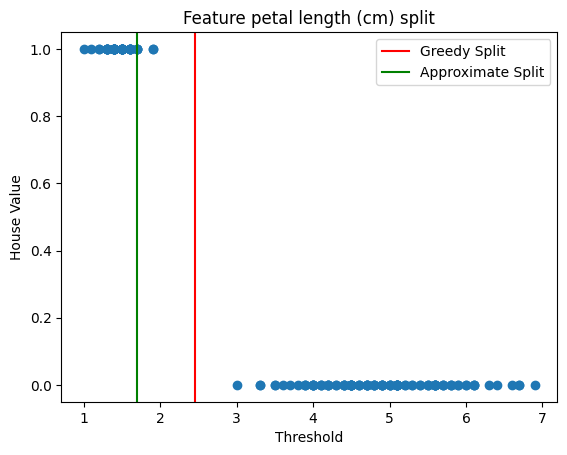

In [6]:
# Test with Iris dataset
iris_data = load_iris()
iris_X = iris_data.data
iris_y = iris_data.target

# Convert to binary
iris_y = (iris_y == 0).astype(float)

iris_y_pred = np.zeros_like(iris_y)
g, h = log_loss_grad_hess(iris_y, iris_y_pred)

# Greedy split
g_feature, g_threshold, g_gain = greedy_split(iris_X, g, h)

print("Best feature:", g_feature)
print("Threshold:", g_threshold)
print("Gain:", g_gain)

# Approximate split
a_feature, a_threshold, a_gain = approx_split_histogram(iris_X, g, h)

print("Best feature:", a_feature)
print("Threshold:", a_threshold)
print("Gain:", a_gain)

plot_split(iris_X, iris_y, g_feature, g_threshold, a_threshold, iris_data.feature_names[g_feature])

Greedy Time: 0.01762540100003207
Best feature: 0
Threshold: 5.1436
Gain: 1585.746426009502
Approx Time: 0.014135150000015528
Best feature: 0
Threshold: 5.347
Gain: 1566.3653607045526


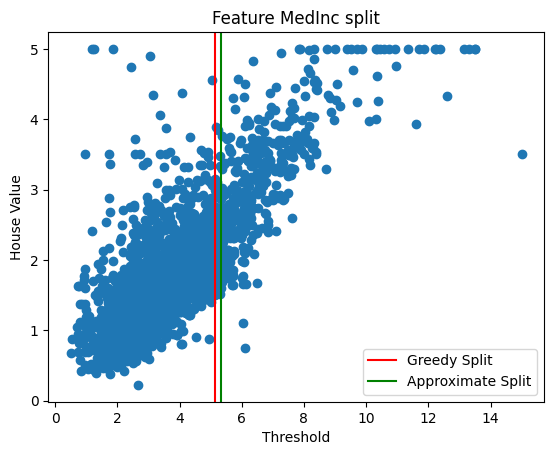

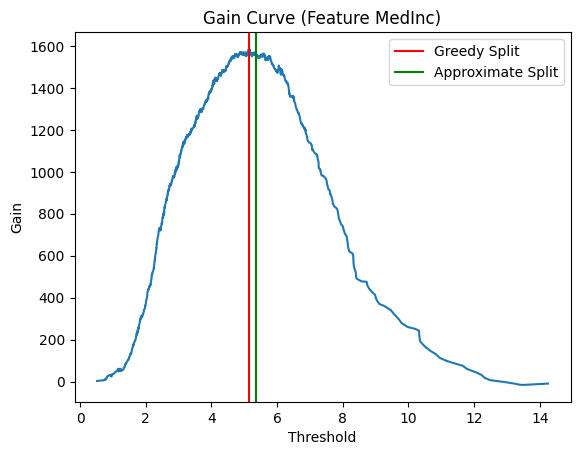

In [7]:
# Test with California Housing dataset
housing_data = fetch_california_housing()
housing_X = housing_data.data
housing_y = housing_data.target

housing_X = housing_X[:2000]
housing_y = housing_y[:2000]

housing_y_pred = np.zeros_like(housing_y)
g, h = log_loss_grad_hess(housing_y, housing_y_pred)

greedy_time_s = time.perf_counter()

# Greedy spit
g_feature, g_threshold, g_gain = greedy_split(housing_X, g, h)

greedy_time_e = time.perf_counter()

print(f"Greedy Time: {greedy_time_e - greedy_time_s}")

print("Best feature:", g_feature)
print("Threshold:", g_threshold)
print("Gain:", g_gain)

approx_time_s = time.perf_counter()

# Approximate spilt
a_feature, a_threshold, a_gain = approx_split_histogram(housing_X, g, h)

approx_time_e = time.perf_counter()

print(f"Approx Time: {approx_time_e - approx_time_s}")

print("Best feature:", a_feature)
print("Threshold:", a_threshold)
print("Gain:", a_gain)

plot_split(housing_X, housing_y, g_feature, g_threshold, a_threshold, housing_data.feature_names[g_feature])

plot_gain_curve(housing_X, g, h, g_feature, g_threshold, a_threshold, housing_data.feature_names[g_feature])

In [8]:
#Repeat the alogorithms 50 times to obtain an mean time value

greedy_times = np.zeros(50)
approx_times = np.zeros(50)

for i in range(50):
  #Greedy split
  greedy_time_s = time.perf_counter()
  g_feature, g_threshold, g_gain = greedy_split(housing_X, g, h)
  greedy_time_e = time.perf_counter()
  greedy_times[i] = greedy_time_e - greedy_time_s

  #Approx split
  approx_time_s = time.perf_counter()
  a_feature, a_threshold, a_gain = approx_split_histogram(housing_X, g, h)
  approx_time_e = time.perf_counter()
  approx_times[i] = approx_time_e - approx_time_s

print("Greedy Times:", greedy_times.mean())
print("Approx Times:", approx_times.mean())

Greedy Times: 0.01908576692000679
Approx Times: 0.01603066335999074
